# Tweedie-modell for ren egen-skadepremie

Tweedie-GLM er utfordreren til den todelte modellen
$\widehat{\text{pure premium}} = \widehat{\text{frekvens}} \times \widehat{\text{severity}}$.
Notebooken bruker bare utviklingsårene 2022–2023; 2024 leses aldri.
Beslutningene ligger i `tweedie_plan.md` (register T-01–T-12).

In [1]:
from functools import partial

import pandas as pd
import statsmodels.api as sm
from IPython.display import display

from src_asserts.common_glm_asserts import (
    assert_full_oof_coverage,
    assert_model_definition,
    assert_valid_folds,
)
from src_asserts.residual_diagnostics_asserts import assert_residual_diagnostics_result
from src_asserts.tweedie_asserts import assert_tweedie_spec, assert_valid_power
from src_core_glm.glm_core import cross_validate_glm, fit_glm, prepare_design_frame
from src_core_glm.model_data import add_seat_category, build_development_frames
from src_core_glm.model_selection import (
    build_specification,
    can_add,
    evaluate_models_parallel,
    propose_additions,
    propose_geography,
    propose_removals,
    propose_spline_forms,
    run_round,
    run_stepwise,
    select_candidate_stage,
)
from src_core_glm.residual_diagnostics import (
    build_residual_diagnostic_summary,
    cross_validate_residual_catboost,
    plot_residual_diagnostic_overview,
)
from src_core_glm.selection_report import (
    build_forward_selection_table,
    build_top_models_table,
)
from src_core_glm.validation import build_group_folds
from src_frequency.frequency_diagnostics import (
    plot_oof_residuals_against_fitted,
    plot_oof_residuals_by_continuous_predictor,
)
from src_severity.severity_data import build_severity_inputs
from src_tweedie.tweedie_data import build_tweedie_frame, summarize_tweedie_frame
from src_tweedie.tweedie_diagnostics import tweedie_deviance_residuals
from src_tweedie.tweedie_power import severity_implied_power

SEED = 100
N_FOLDS = 5
SE_MULTIPLIER = 1.0  # fjerde seleksjonskrav (§4): snittgevinst > 1 standardfeil
N_JOBS = 8  # parallelle prosesser for kandidat-CV (resultatene er de samme som med 1)

## 1. Datagrunnlag

La $S_i$ være `property_incurred`, $e_i$ være `total_exposure` og
$R_i = S_i/e_i$ observert pure premium per eksponeringsår. Alle poliseår er
gyldige observasjoner, også skadefrie ($R_i = 0$), og flere skader på samme
poliseår er tillatt fordi $S_i$ er aggregert årlig skadekostnad.

In [2]:
frames = build_development_frames()
development = frames["development"]

# Kolonnene som er tilgjengelige for modellene. Selve modellvalget står i §3.
AVAILABLE_COLUMNS = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seats",
]
model_frame = build_tweedie_frame(development, AVAILABLE_COLUMNS)
add_seat_category(model_frame)  # seter som <5, =5, >5 (som i severity)
display(summarize_tweedie_frame(model_frame).round(3))

,Poliseår,Sum eksponering,Sum incurred (EUR),Skadefrie poliseår (andel),Unike insured_id
0,55246,37126.014,8708120.16,0.897,37305


## 2. Validering

Fem gruppefolder på `insured_id` bygges på hele modellpopulasjonen. Samme
indeks, gruppekolonne og seed gir identiske folder som i frekvens- og
severity-notebookene, slik at OOF-prediksjonene kan sammenlignes rad for rad.

In [3]:
cv_folds = build_group_folds(
    model_frame,
    group_column="insured_id",
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)
assert_valid_folds(cv_folds, model_frame)  # sanity-sjekk, kan fjernes

## 3. Modellspesifikasjon

$$
R_i = \frac{S_i}{e_i} \sim \operatorname{Tweedie}\!\left(\mu_i, \frac{\phi}{e_i}, p\right),
\qquad 1<p<2,
$$

$$
\operatorname{E}[R_i \mid x_i] = \mu_i,
\qquad
\operatorname{Var}(R_i \mid x_i) = \frac{\phi}{e_i}\,\mu_i^{p},
\qquad
\log \mu_i = \beta_0 + \sum_j f_j(x_{ij}) + \sum_{(j,k)} \gamma_{jk}\, x_{ij} x_{ik}.
$$

Her er $f_j$ enten lineær ($\beta_j x_{ij}$) eller en naturlig kubisk spline, og
$\gamma_{jk}$ er en interaksjon mellom to variabler. For $1<p<2$ er $R_i$ en
sammensatt Poisson–Gamma-variabel: masse i null (skadefrie år) og en
kontinuerlig positiv del. Eksponeringen $e_i$ er `var_weights`, uten offset:
$R_i$ er allerede en rate, og et år med høy eksponering er en mer presis
observasjon av samme $\mu_i$.

Power $p$ utledes én gang fra severity-dispersjonen til en bred ankermodell (§4.1)
og låses *før* seleksjonen (deviance med ulike $p$ er ikke sammenlignbar, så $p$
velges ikke ved CV).

In [4]:
# Hvilke variabler som er hva. Seleksjonen under leser bare disse listene.
LOCKED = ["policy_type", "year"]  # alltid med, fjernes aldri
CORE = ["circulation_area", "log_vehicle_value", "driver_age"]  # startmodell K0
GEOGRAPHY = "municipality_type"  # testes mot og sammen med circulation_area
ADDITIONAL = [  # tillegg: legges til én om gangen, så lenge de forbedrer modellen
    "performance_hp_per_tonne",
    "fuel_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seat_category",
]
INTERACTIONS = [  # testes bare når begge hovedeffektene allerede er med
    ("driver_age", "performance_hp_per_tonne"),
    ("driver_age", "policy_type"),
    ("driver_age", "log_vehicle_value"),
]

# En modell er en liste med termer (kolonne eller interaksjon) og eventuelle splines.
definitions = {"K0": {"terms": [*LOCKED, *CORE], "splines": {}}}

In [5]:
def build_tweedie_specification(name, definition, power):
    """Bygg Tweedie-spesifikasjonen (log-link, eksponeringsvekt, ingen offset)."""
    settings = {
        "y": "pure_premium",
        "family": sm.families.Tweedie(var_power=power, link=sm.families.links.Log()),
        "weight": "total_exposure",
        "power": power,
    }
    return build_specification(name, definition, model_frame, settings)


assert_tweedie_spec(
    build_tweedie_specification("K0", definitions["K0"], 1.5)
)  # kan fjernes

## 4. Sammenligning og valg

Alle trinn bruker den samme firleddsregelen: en kandidat velges bare hvis den har
**lavere pooled OOF-deviance** enn foreldremodellen, er **bedre i minst fire av
fem folder**, har **gyldig fit i alle folder** og har en **snittgevinst over én
standardfeil**. Med $d_k$ = foreldrens minus kandidatens deviance i fold $k$ er
siste krav

$$\bar d > \frac{s_d}{\sqrt{5}}, \qquad \bar d = \tfrac15\sum_k d_k.$$

Kravet hindrer at små, støydrevne gevinster slipper inn; det er en grov
støyfilter, ikke en formell test (fem folder gir et usikkert $s_d$).

| Trinn | Type | Kandidater |
|---|---|---|
| 4.2–4.3 Funksjonsform | ett valg | alder: spline df 2, 3, 4; bilverdi: spline df 3 |
| 4.4 Geografi | ett valg | `municipality_type` i stedet for, eller i tillegg til, `circulation_area` |
| 4.5 Tillegg | forover-løkke | `ADDITIONAL`, én om gangen til ingen består |
| 4.6 Interaksjoner | forover-løkke | `INTERACTIONS` |
| 4.7 Ablasjon | bakover-løkke | alle termer unntatt `LOCKED` |

Ablasjonen kan ikke fjerne en hovedeffekt så lenge en interaksjon bruker den.
Utviklingsscoren er litt optimistisk fordi mange kandidater sammenlignes på de
samme foldene; 2024 er den uavhengige kontrollen og er ikke berørt.

### 4.1 Låsing av $p$ fra severity-dispersjonen

En Tweedie med $1<p<2$ er en sammensatt Poisson–Gamma-variabel. Er skadestørrelsen
Gamma med dispersjon $\phi_s$ (= CV$^2$), er

$$p = \frac{1 + 2\phi_s}{1 + \phi_s}.$$

$\phi_s$ hentes fra en Gamma-GLM på snittskade (vekt = antall skader, samme
severity-utvalg som i severity-notebooken) med en bred ankermodell: låste
variabler, kjerne, `municipality_type` og alle tillegg, lineært.

> **Limitation (bør vurderes utvidet).** $p$ er svakt identifisert i disse dataene,
> og metoden hviler på to antakelser: Gamma-fordelte skader med konstant CV, og at
> dispersjonen er lik for alle poliser. Estimatet er følsomt for storskadene: uten
> de 1 % største snittskadene faller det fra ca. 1,74 til ca. 1,62. Pearson-estimering
> direkte på Tweedie-modellen ble forsøkt (T-05), men ga ingen gyldig rot i $(1,2)$.
> Mulige utvidelser: profilelikelihood over et $p$-gitter (krever eksakt
> Tweedie-tetthet), eller en sensitivitetsanalyse av sluttmodellen ved andre $p$.

In [6]:
severity_frame = build_severity_inputs(development)["severity_frame"]
anchor_terms = [*LOCKED, *CORE, GEOGRAPHY, *ADDITIONAL]
power_estimate = severity_implied_power(severity_frame, anchor_terms)
TWEEDIE_POWER = power_estimate["power"]
assert_valid_power(TWEEDIE_POWER)  # sanity-sjekk, kan fjernes
print(
    f"Severity-dispersjon φ_s = {power_estimate['dispersion']:.3f} "
    f"({power_estimate['n_severity_rows']} skadepoliseår)  →  låst p = {TWEEDIE_POWER:.3f}"
)

Severity-dispersjon φ_s = 2.902 (5698 skadepoliseår)  →  låst p = 1.744


In [7]:
cv_results, specifications = {}, {}


def evaluate_model(name):
    """Bygg spesifikasjonen og kjør CV for én modelldefinisjon."""
    assert_model_definition(definitions[name], LOCKED)  # sanity-sjekk, kan fjernes
    specification = build_tweedie_specification(name, definitions[name], TWEEDIE_POWER)
    return specification, cross_validate_glm(specification, model_frame, cv_folds)


def evaluate_models(names):
    """Kjør CV for flere modelldefinisjoner parallelt (én prosess per kandidat)."""
    evaluate_models_parallel(evaluate_model, specifications, cv_results, N_JOBS, names)


# Firleddsregelen med låst p; kalles som select_stage(foreldre, kandidatnavn).
select_stage = partial(
    select_candidate_stage,
    cv_results,
    response=model_frame["pure_premium"],
    sample_weight=model_frame["total_exposure"],
    power=TWEEDIE_POWER,
    se_multiplier=SE_MULTIPLIER,
)

evaluate_models(["K0"])

### 4.2 Funksjonsform: alder

Lineær alder (K0) utfordres av naturlig kubisk spline med 2, 3 og 4
frihetsgrader. Bare én aldersform kan velges.

In [8]:
core = definitions["K0"]
age_alternatives = propose_spline_forms(core, "driver_age", "alder", (2, 3, 4))
age_model, age_table = run_round(
    "K0", age_alternatives, definitions, evaluate_models, select_stage
)
display(age_table.round(4))
print(f"Valgt etter aldersform: {age_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df2,33.3244,True,False,True,0.0084,0.0071,True,,+alder_df2,False
K0+alder_df3,33.3220,True,True,True,0.0109,0.0087,True,,+alder_df3,True
K0+alder_df4,33.3208,True,False,True,0.0121,0.0108,True,,+alder_df4,False


Valgt etter aldersform: K0+alder_df3


### 4.3 Funksjonsform: bilverdi

`log_vehicle_value` utfordres av en spline med 3 frihetsgrader.

In [9]:
current = definitions[age_model]
value_alternatives = propose_spline_forms(
    current, "log_vehicle_value", "bilverdi", (3,)
)
value_model, value_table = run_round(
    age_model, value_alternatives, definitions, evaluate_models, select_stage
)
display(value_table.round(4))
print(f"Valgt etter bilverdi: {value_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df3+bilverdi_df3,33.3241,False,False,True,-0.0021,0.0054,False,,+bilverdi_df3,False


Valgt etter bilverdi: K0+alder_df3


### 4.4 Geografi

`circulation_area` (U/R) er med i kjernen. `municipality_type` (I/C/IS) testes
enten *i stedet for* `circulation_area` eller *i tillegg til* den. Bare ett
alternativ kan velges.

In [10]:
current = definitions[value_model]
geography_alternatives = propose_geography(current, GEOGRAPHY, "circulation_area")
geography_model, geography_table = run_round(
    value_model, geography_alternatives, definitions, evaluate_models, select_stage
)
display(geography_table.round(4))
print(f"Valgt etter geografi: {geography_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df3+municipality_type,33.3435,False,False,True,-0.0216,0.0185,False,,+municipality_type,False
K0+alder_df3_bytt_til_municipality_type,33.3425,False,False,True,-0.0207,0.0215,False,,_bytt_til_municipality_type,False


Valgt etter geografi: K0+alder_df3


### 4.5 Tillegg

Forover-seleksjon: beste tillegg som består regelen legges til, og de
gjenstående testes på nytt mot den nye modellen. Løkken stopper når ingen
tillegg består. Flere tillegg kan altså komme inn.

In [11]:
additions_model, additions_table = run_stepwise(
    geography_model,
    propose_additions(ADDITIONAL),
    definitions,
    evaluate_models,
    select_stage,
)
display(additions_table.round(4))
print(f"Valgt etter tillegg: {additions_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0+alder_df3+performance_hp_per_tonne,33.3301,False,False,True,-0.0082,0.0075,False,,+performance_hp_per_tonne,False,1
K0+alder_df3+fuel_type,33.3081,True,True,True,0.0138,0.0092,True,,+fuel_type,False,1
K0+alder_df3+payment_frequency,33.3013,True,True,True,0.0206,0.0160,True,,+payment_frequency,True,1
K0+alder_df3+business_type,33.3073,True,True,True,0.0146,0.0053,True,,+business_type,False,1
K0+alder_df3+vehicle_brand_pooled,33.3748,False,False,True,-0.0529,0.0569,False,,+vehicle_brand_pooled,False,1
K0+alder_df3+seat_category,33.3108,True,True,True,0.0113,0.0102,True,,+seat_category,False,1
K0+alder_df3+payment_frequency+performance_hp_per_tonne,33.3098,False,False,True,-0.0084,0.0075,False,,+performance_hp_per_tonne,False,2
K0+alder_df3+payment_frequency+fuel_type,33.2868,True,True,True,0.0145,0.0096,True,,+fuel_type,True,2
K0+alder_df3+payment_frequency+business_type,33.2871,True,True,True,0.0143,0.0055,True,,+business_type,False,2


Valgt etter tillegg: K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type


### 4.6 Interaksjoner

Samme forover-løkke. En interaksjon testes bare når begge hovedeffektene er i
modellen, ellers hadde testen lagt til to ting samtidig.

In [12]:
interaction_model, interaction_table = run_stepwise(
    additions_model,
    propose_additions(INTERACTIONS),
    definitions,
    evaluate_models,
    select_stage,
)
display(interaction_table.round(4))
final_definition = definitions[interaction_model]
not_tested = [
    term
    for term in INTERACTIONS
    if term not in final_definition["terms"] and not can_add(final_definition, term)
]
print(f"Valgt etter interaksjoner: {interaction_model}")
print(f"Ikke testet (mangler hovedeffekt): {not_tested or 'ingen'}")

/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type+driver_age*policy_type,NaN,False,False,False,0.0005,0.0020,False,gruppe_1: rangsvikt (16 av 17 kolonner); grupp...,+driver_age*policy_type,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type+driver_age*log_vehicle_value,33.2511,True,True,True,0.0062,0.0097,False,,+driver_age*log_vehicle_value,False,1


Valgt etter interaksjoner: K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type
Ikke testet (mangler hovedeffekt): [('driver_age', 'performance_hp_per_tonne')]


### 4.7 Ablasjon

Bakover-løkke: én term fjernes om gangen fra modellen som nå er valgt (alt
unntatt `LOCKED`), og fjerningen beholdes bare når den oppfyller den samme
firleddsregelen. Gjentas til ingen fjerning består.

In [13]:
final_model, ablation_table = run_stepwise(
    interaction_model,
    propose_removals(set(LOCKED)),
    definitions,
    evaluate_models,
    select_stage,
)
display(ablation_table.round(4))
print(f"Valgt etter ablasjon: {final_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-circulation_area,33.2575,False,False,True,-0.0003,0.0061,False,,-circulation_area,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-log_vehicle_value,33.4029,False,False,True,-0.1461,0.0500,False,,-log_vehicle_value,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-driver_age,33.2706,False,False,True,-0.0134,0.0079,False,,-driver_age,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-payment_frequency,33.2792,False,False,True,-0.0220,0.0163,False,,-payment_frequency,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-fuel_type,33.2741,False,False,True,-0.0169,0.0089,False,,-fuel_type,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-seat_category,33.2727,False,False,True,-0.0156,0.0092,False,,-seat_category,False,1
K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type-business_type,33.2719,False,False,True,-0.0146,0.0051,False,,-business_type,False,1


Valgt etter ablasjon: K0+alder_df3+payment_frequency+fuel_type+seat_category+business_type


### 4.8 Forover-seleksjon: hva tilfører verdi?

Én rad per valgt steg i funksjonsform (§4.2–4.4), tillegg (§4.5) og
interaksjoner (§4.6); ablasjonen (§4.7) står i sin egen tabell. `oof_deviance` er
pooled OOF for modellen etter steget (utviklingsscore, ikke en uavhengig
evaluering). `snitt_gevinst` er snittet av fold-gevinstene mot foreldremodellen,
`se_gevinst` er standardfeilen, og `gevinst_i_se` er forholdet mellom dem. Rundt
1 er marginalt: når flere kandidater sammenlignes, ligger den beste ofte på ca.
1–1,5 SE selv uten noe ekte signal. Tydelig verdi krever vesentlig mer.

In [14]:
display(
    build_forward_selection_table(
        [age_table, value_table, geography_table, additions_table, interaction_table]
    ).round(4)
)
assert_model_definition(definitions[final_model], LOCKED)  # sanity-sjekk, kan fjernes
print("Valgt Tweedie-modell:", definitions[final_model])
print("Spesifikasjonen er ikke låst før den er godkjent. 2024 er ikke berørt.")

,endring,oof_deviance,snitt_gevinst,se_gevinst,gevinst_i_se
steg,,,,,
1,+alder_df3,33.3220,0.0109,0.0087,1.2540
2,+payment_frequency,33.3013,0.0206,0.0160,1.2908
3,+fuel_type,33.2868,0.0145,0.0096,1.5210
4,+seat_category,33.2719,0.0150,0.0094,1.5903
5,+business_type,33.2572,0.0146,0.0051,2.8708


Valgt Tweedie-modell: {'terms': ['policy_type', 'year', 'circulation_area', 'log_vehicle_value', 'driver_age', 'payment_frequency', 'fuel_type', 'seat_category', 'business_type'], 'splines': {'driver_age': 3}}
Spesifikasjonen er ikke låst før den er godkjent. 2024 er ikke berørt.


### 4.9 Konkurrerende modeller

Blant alle modeller som er evaluert i seleksjonen vises de tre med lavest pooled
OOF-deviance. `endring` viser hva som skiller dem fra den valgte modellen,
`parametere` er antall koeffisienter (inkludert konstantledd) og
`delta_mot_valgt` er OOF-deviance minus den valgtes (negativ = lavere). Er en
enklere modell praktisk talt like god (liten delta målt mot SE i §4.8), er den å
foretrekke. En mer kompleks modell med lavere deviance er bare interessant hvis
forskjellen er tydelig over støyen. Tabellen er beslutningsgrunnlag og endrer ikke
seleksjonsregelen.

In [15]:
top_models = build_top_models_table(
    cv_results,
    definitions,
    final_model,
    model_frame["pure_premium"],
    model_frame["total_exposure"],
    TWEEDIE_POWER,
)
with pd.option_context("display.max_colwidth", None):
    display(top_models.reset_index(drop=True).round(4))

,endring,variabler,parametere,oof_deviance,delta_mot_valgt
0,+ driver_age*log_vehicle_value,"policy_type, year, circulation_area, log_vehicle_value, driver_age (spline df 3), payment_frequency, fuel_type, seat_category, business_type, driver_age*log_vehicle_value",16,33.2511,-0.0061
1,valgt modell,"policy_type, year, circulation_area, log_vehicle_value, driver_age (spline df 3), payment_frequency, fuel_type, seat_category, business_type",15,33.2572,0.0000
2,− circulation_area,"policy_type, year, log_vehicle_value, driver_age (spline df 3), payment_frequency, fuel_type, seat_category, business_type",14,33.2575,0.0002


### 4.10 Valgt modell: koeffisienter

Den valgte modellen estimeres på alle utviklingsdata (2022–2023) med
cluster-robuste standardfeil på `insured_id`, som i frekvens- og severity-notebookene.
Koeffisientene er log-relativiteter i dette datasettet, ikke kausale effekter.

In [16]:
final_specification = specifications[final_model]
final_design = prepare_design_frame(
    model_frame, model_frame, final_specification["required_columns"]
)
final_fit = fit_glm(
    final_specification, final_design, cluster_groups=final_design["insured_id"]
)
display(final_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:           pure_premium   No. Observations:                55246
Model:                            GLM   Df Residuals:                    55231
Model Family:                 Tweedie   Df Model:                           14
Link Function:                    Log   Scale:                          102.53
Method:                          IRLS   Log-Likelihood:                -67811.
Date:                Sat, 19 Sep 2026   Deviance:                   1.2325e+06
Time:                        17:33:40   Pearson chi2:                 5.66e+06
No. Iterations:                    16   Pseudo R-squ. (CS):           0.005958
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                        -0.2447      0.611     -0.401      0.689      -1.442       0.952
C(policy_type, Treatment('COMP_E'))[T.COMP_N]     0.8917      0.041     21.870      0.000       0.812       0.972
C(year, Treatment(2023))[T.2022]                 -0.0322      0.050     -0.647      0.518      -0.130       0.065
C(circulation_area, Treatment('U'))[T.R]         -0.0651      0.045     -1.445      0.149      -0.153       0.023
C(payment_frequency, Treatment('A'))[T.Q]         0.3864      0.089      4.344      0.000       0.212       0.561
C(payment_frequency, Treatment('A'))[T.S]         0.0301      0.064      0.472      0.637      -0.095       0.155
C(fuel_type, Treatment('D'))[T.G]                -0.1838      0.056     -3.300      0.001      -0.293      -0.075
C(fuel_type, Treatment('D'))[T.MISSING]          -0.0828      0.175     -0.472      0.637      -0.427       0.261
C(seat_category, Treatment('=5'))[T.<5]          -0.0246      0.091     -0.272      0.785      -0.202       0.153
C(seat_category, Treatment('=5'))[T.>5]          -0.2583      0.066     -3.929      0.000      -0.387      -0.129
C(business_type, Treatment('NB'))[T.P]            0.1496      0.047      3.160      0.002       0.057       0.242
log_vehicle_value                                 0.5320      0.059      9.064      0.000       0.417       0.647
cr(driver_age, df=3, constraints='center')[0]    -0.2992      0.215     -1.392      0.164      -0.721       0.122
cr(driver_age, df=3, constraints='center')[1]    -0.0398      0.105     -0.381      0.704      -0.245       0.165
cr(driver_age, df=3, constraints='center')[2]     0.3049      0.232      1.314      0.189      -0.150       0.760
=================================================================================================================
"""

## 5. CatBoost-diagnostikk av residualstruktur

Vi spør om det finnes struktur i middelverdien som den valgte Tweedie-GLM-en
ikke fanger. CatBoost er kun en diagnose og velger aldri GLM-variabler.

$$
z_i=\frac{R_i}{\hat\mu_{i,\mathrm{inner\ OOF}}},
\qquad
a_i=e_i\,\hat\mu_{i,\mathrm{inner\ OOF}}^{\,2-p},
\qquad
\hat\mu_i^*=\hat\mu_{i,\mathrm{GLM}}\,\hat h(x_i).
$$

$z_i$ er observert pure premium relativt til GLM-prediksjonen (rundt 1 hvis
GLM-en treffer), $a_i$ er radens vekt med det låste $p$, og $\hat h(x)$ er
CatBoosts korreksjonsfaktor lært med Poisson-loss. **Indre CV** (fem nye
`insured_id`-folder inne i hver ytre treningsdel) lager $z_i$, så CatBoost
aldri trener på prediksjoner fra en GLM som har sett raden. **Ytre CV** måler
gevinsten på forsikrede CatBoost ikke har sett. Dybde 1 er additiv, dybde 3 kan
også fange interaksjoner.

In [17]:
residual_diagnostics = cross_validate_residual_catboost(
    final_specification,
    model_frame,
    cv_folds,
    final_specification["required_columns"],
    categorical_columns=tuple(final_specification["base_levels"]),
    blocked_feature_columns=("property_incurred", "pure_premium"),  # responsen
    seed=SEED,
)
assert_residual_diagnostics_result(
    residual_diagnostics, model_frame, cv_folds
)  # kan fjernes

### 5.1 Finnes det residualstruktur?

Tabellen sammenligner GLM-en med en konstant korreksjon (bare nivå) og to
CatBoost-dybder, beregnet på alle OOF-rader. `delta_*` er reduksjon i deviance
(positivt er bedre), `better_than_*_folds` teller ytre folder med gevinst og
`oof_ae` er faktisk delt på predikert skadekostnad.

In [18]:
display(build_residual_diagnostic_summary(residual_diagnostics).round(4))

,benchmark,pooled_oof_deviance,delta_vs_glm,relative_gain_vs_glm,delta_vs_constant,delta_vs_depth_1,better_than_glm_folds,better_than_constant_folds,better_than_depth_1_folds,oof_ae,valid
0,glm,33.2572,0.0000,0.0000,-0.0006,NaN,0,3,NaN,1.0011,True
1,constant,33.2567,0.0006,0.0000,0.0000,NaN,2,0,NaN,0.9923,True
2,catboost_depth_1,33.2585,-0.0012,-0.0000,-0.0018,NaN,4,3,NaN,0.9912,True
3,catboost_depth_3,33.2512,0.0061,0.0002,0.0055,0.0073,4,3,3.0,0.9953,True


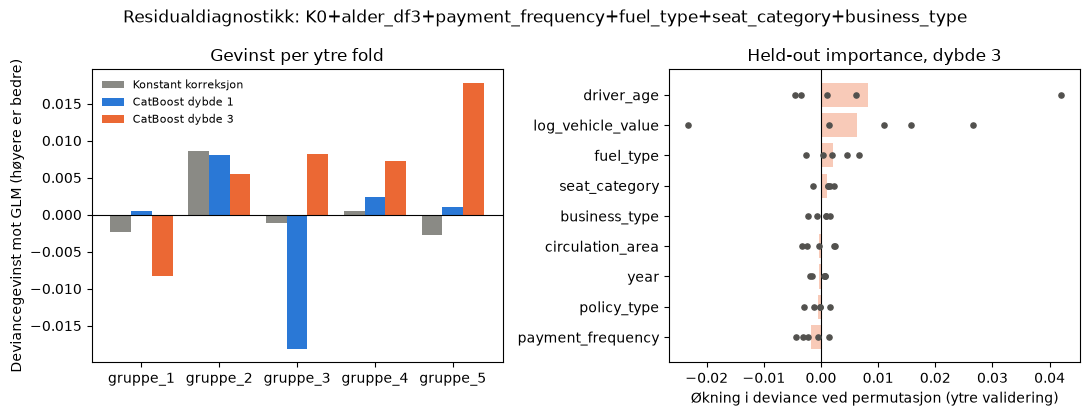

In [19]:
residual_overview_figure = plot_residual_diagnostic_overview(residual_diagnostics)

**Begrensning.** GLM-en er valgt ved gjentatt bruk av de samme ytre foldene.
Diagnostikken er derfor en utviklingsdiagnose, ikke en uavhengig test og ikke
en evaluering av hele seleksjonsprosedyren. Fravær av gevinst er ikke bevis for
fravær av struktur: skadekostnaden er skjev og dominert av få storskader, så
den statistiske styrken er lav.

## 6. OOF-diagnostikk av Tweedie-GLM-en

Residualene er eksponeringsvektede Tweedie deviance-residualer, beregnet fra
prediksjoner fra folden der poliseåret ikke inngikk i tilpasningen. Skadefrie år
ligger i et eget negativt bånd (residualen er da bare en funksjon av
$\hat\mu_i$), så spredningen er ikke normal. LOWESS-kurvene er visuelle
hjelpemidler, ikke hypotesetester, og bør ligge nær null.

Frekvensnotebookens rootogram er utelatt: det teller heltallige skadeantall,
mens Tweedie-responsen er kontinuerlig med punktmasse i null.

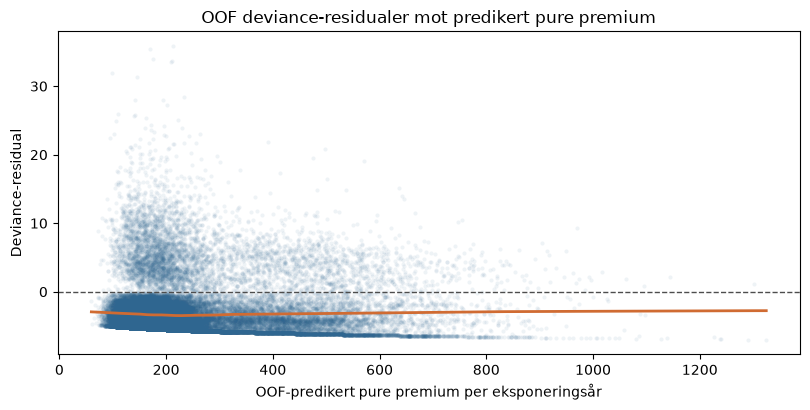

In [20]:
oof_premium = cv_results[final_model]["oof"]
assert_full_oof_coverage(oof_premium, model_frame.index, "Tweedie-OOF")  # kan fjernes
oof_residuals = tweedie_deviance_residuals(
    model_frame["pure_premium"],
    oof_premium,
    model_frame["total_exposure"],
    TWEEDIE_POWER,
)
oof_fitted_figure = plot_oof_residuals_against_fitted(
    oof_premium,
    oof_residuals,
    xlabel="OOF-predikert pure premium per eksponeringsår",
    title="OOF deviance-residualer mot predikert pure premium",
)

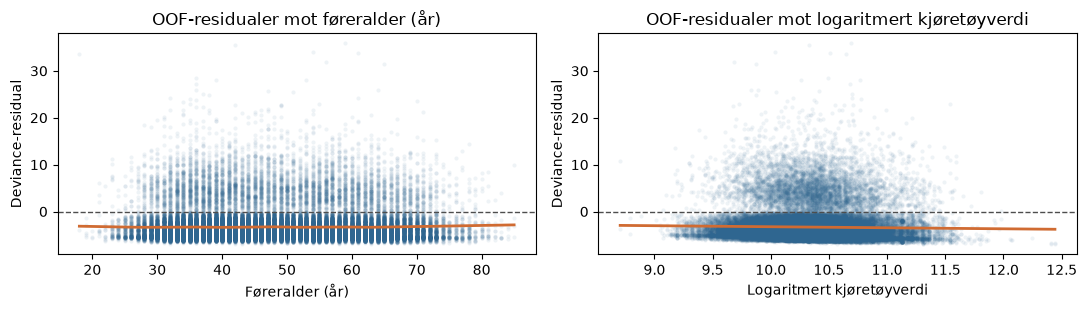

In [21]:
continuous_predictors = [
    predictor
    for predictor in ["driver_age", "log_vehicle_value", "performance_hp_per_tonne"]
    if predictor in final_specification["required_columns"]
]
oof_predictor_figure = plot_oof_residuals_by_continuous_predictor(
    model_frame, continuous_predictors, oof_residuals
)